## 1. Imports and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:

tickers = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}

all_tickers = [ticker for sector in tickers.values() for ticker in sector]



In [3]:
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(
    [ticker for sector in tickers.values() for ticker in sector],
    start=start_date,
    end=end_date,
    interval = "1mo"
)["Close"]

# Compute returns
returns = np.log(data).diff().dropna()

# Data Quality Checks
# 1. Are there any NaNs?
print(returns.isna().sum().sum())

# 2. Are they at the start?
print(returns.iloc[0].isna().sum())

# 3. Flag outliers (returns > 50% or < -50%)
outliers = (returns > 0.5) | (returns < -0.5)
outliers_df = returns[outliers].stack(level = 'Ticker')
print(outliers_df)

data.to_csv("data/prices.csv")
returns.to_csv("data/returns.csv")

C:\Users\godwi\AppData\Local\Temp\ipykernel_35300\1760627635.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  60 of 60 completed


0
0
Date        Ticker
2013-05-01  TSLA      0.593717
2016-02-01  FCX       0.506032
2020-03-01  EOG      -0.565959
            SLB      -0.682553
            SPG      -0.792846
2020-08-01  TSLA      0.554719
2022-04-01  NFLX     -0.676915
dtype: float64


In [4]:
# Compare to benchmark
spy_row = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval = "1mo"
)

spy_prices = spy_row["Close"]["SPY"]

spy_returns = np.log(spy_prices).diff().dropna()
spy_returns = spy_returns.reindex(returns.index)
spy_returns.to_csv("data/spy_returns.csv")

# Check shape
print(returns.shape)        # (T, N)
print(spy_returns.shape)    # (T,)
# Confirm all share the same index
assert returns.index.equals(spy_returns.index)

assert len(returns) == len(spy_returns), \
    "returns and spy_returns have different lengths"


C:\Users\godwi\AppData\Local\Temp\ipykernel_35300\2373587483.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_row = yf.download(
[*********************100%***********************]  1 of 1 completed

(143, 60)
(143,)


## 2. Raw Signals

In [5]:
# Pull Fundamental Data
# Market Cap
shares_dict = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_dict[ticker] = shares
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        shares_dict[ticker] = None

shares_series = pd.Series(shares_dict)
missing = shares_series[shares_series.isna()]
print(missing) # None
market_cap = data.multiply(shares_series, axis=1)
market_cap.to_csv("data/market_cap.csv")
log_market_cap = np.log(market_cap)
log_market_cap.to_csv("data/log_market_cap.csv")

print(log_market_cap.shape) # 120 Months x 60 stocks
print(log_market_cap.head())

Series([], dtype: int64)
(180, 60)
                 AAPL  ABBV        AEP        AMT       AMZN        APD  \
Date                                                                      
2010-01-01  25.159348   NaN  23.028371  23.384754  24.934689  23.064724   
2010-02-01  25.222695   NaN  22.998194  23.389688  24.877169  22.962518   
2010-03-01  25.361126   NaN  23.026976  23.388515  25.014063  23.037906   
2010-04-01  25.466405   NaN  23.030481  23.345354  25.023811  23.082078   
2010-05-01  25.450149   NaN  22.959821  23.338469  24.935087  22.976109   

                 AVGO        BAC        BLK        CAT  ...        SLB  \
Date                                                    ...              
2010-01-01  22.483284  25.137923  23.804409  23.500736  ...  24.882614   
2010-02-01  22.526635  25.230955  23.827433  23.595615  ...  24.844715   
2010-03-01  22.651312  25.299948  23.822668  23.692438  ...  24.885862   
2010-04-01  22.648877  25.299435  23.658849  23.772518  ...  25.00403

In [6]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
# Compute Raw Signal Values
# 1. Market Beta
# Run OLS over past 36 months
beta_window = 36
monthly_index = returns.index
beta_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

assert returns.index.equals(spy_returns.index), \
    "returns and spy_returns have different indices — align them first"

for i, date in enumerate(monthly_index):
    if i < beta_window:
        continue  # Not enough data for the first few months


    window_returns = returns.iloc[i-beta_window:i]
    window_spy = spy_returns.iloc[i-beta_window:i]
    
    valid_mask = window_spy.notna() 
    if valid_mask.sum() < 24:
        continue

    spy_window_clean = window_spy[valid_mask] 

    for ticker in all_tickers:
        y = window_returns.loc[window_spy.index, ticker]

        combined_valid = valid_mask & y.notna()

        if combined_valid.sum() < 24: 
            continue

        y_clean = y[combined_valid].values
        spy_clean = window_spy[combined_valid].values
        X_clean = add_constant(spy_clean, has_constant="add")  # Recreate X with cleaned spy data

        try:
            model = OLS(y_clean, X_clean).fit()
            beta_panel.loc[date, ticker] = model.params[1]  # Store the beta coefficient

        except Exception:
            pass

beta_panel.to_csv("data/signal_beta_raw.csv")


    

In [7]:
# Sanity check
print((beta_panel < -1).sum().sum())
print((beta_panel > 3).sum().sum()) 
beta_panel.describe()

0
10


,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,1.209815,0.997647,1.680790,0.976278,1.234582,1.125009,1.450089,1.319077,1.382782,1.402045,...,0.981958,0.642063,0.563062,1.194144,0.372518,0.889349,0.904857,0.278360,2.168965,1.172563
std,0.126090,0.192603,0.516003,0.233434,0.180872,0.081986,0.174439,0.130643,0.185241,0.197813,...,0.185710,0.360573,0.261461,0.673906,0.296590,0.211928,0.177428,0.275047,0.480578,0.146816
min,0.857281,0.723169,0.889584,0.347593,0.938764,0.908344,1.129595,1.007939,0.968408,1.069550,...,0.720755,0.005012,0.143121,0.270697,-0.111231,0.431365,0.667351,-0.395555,1.354607,0.952004
25%,1.164759,0.837107,1.281466,0.874298,1.089718,1.058656,1.261482,1.222512,1.251679,1.208763,...,0.855899,0.256175,0.342740,0.523967,0.130961,0.743161,0.758974,0.169748,1.749973,1.042353
50%,1.204453,0.983618,1.403220,0.977349,1.214377,1.137257,1.528629,1.313535,1.438041,1.428780,...,0.945991,0.811598,0.554161,1.419556,0.348467,0.955598,0.855405,0.370040,2.118406,1.140323
75%,1.281390,1.117177,2.234355,1.166203,1.348520,1.179551,1.580496,1.417254,1.529229,1.574080,...,1.066045,0.954312,0.652691,1.872234,0.510101,1.081161,1.049468,0.443178,2.477957,1.270549
max,1.493851,1.435643,2.678075,1.353742,1.609264,1.363187,1.736352,1.619204,1.663062,1.676584,...,1.425440,1.133306,1.104263,2.220804,0.965901,1.175876,1.329905,0.856158,3.190325,1.470353


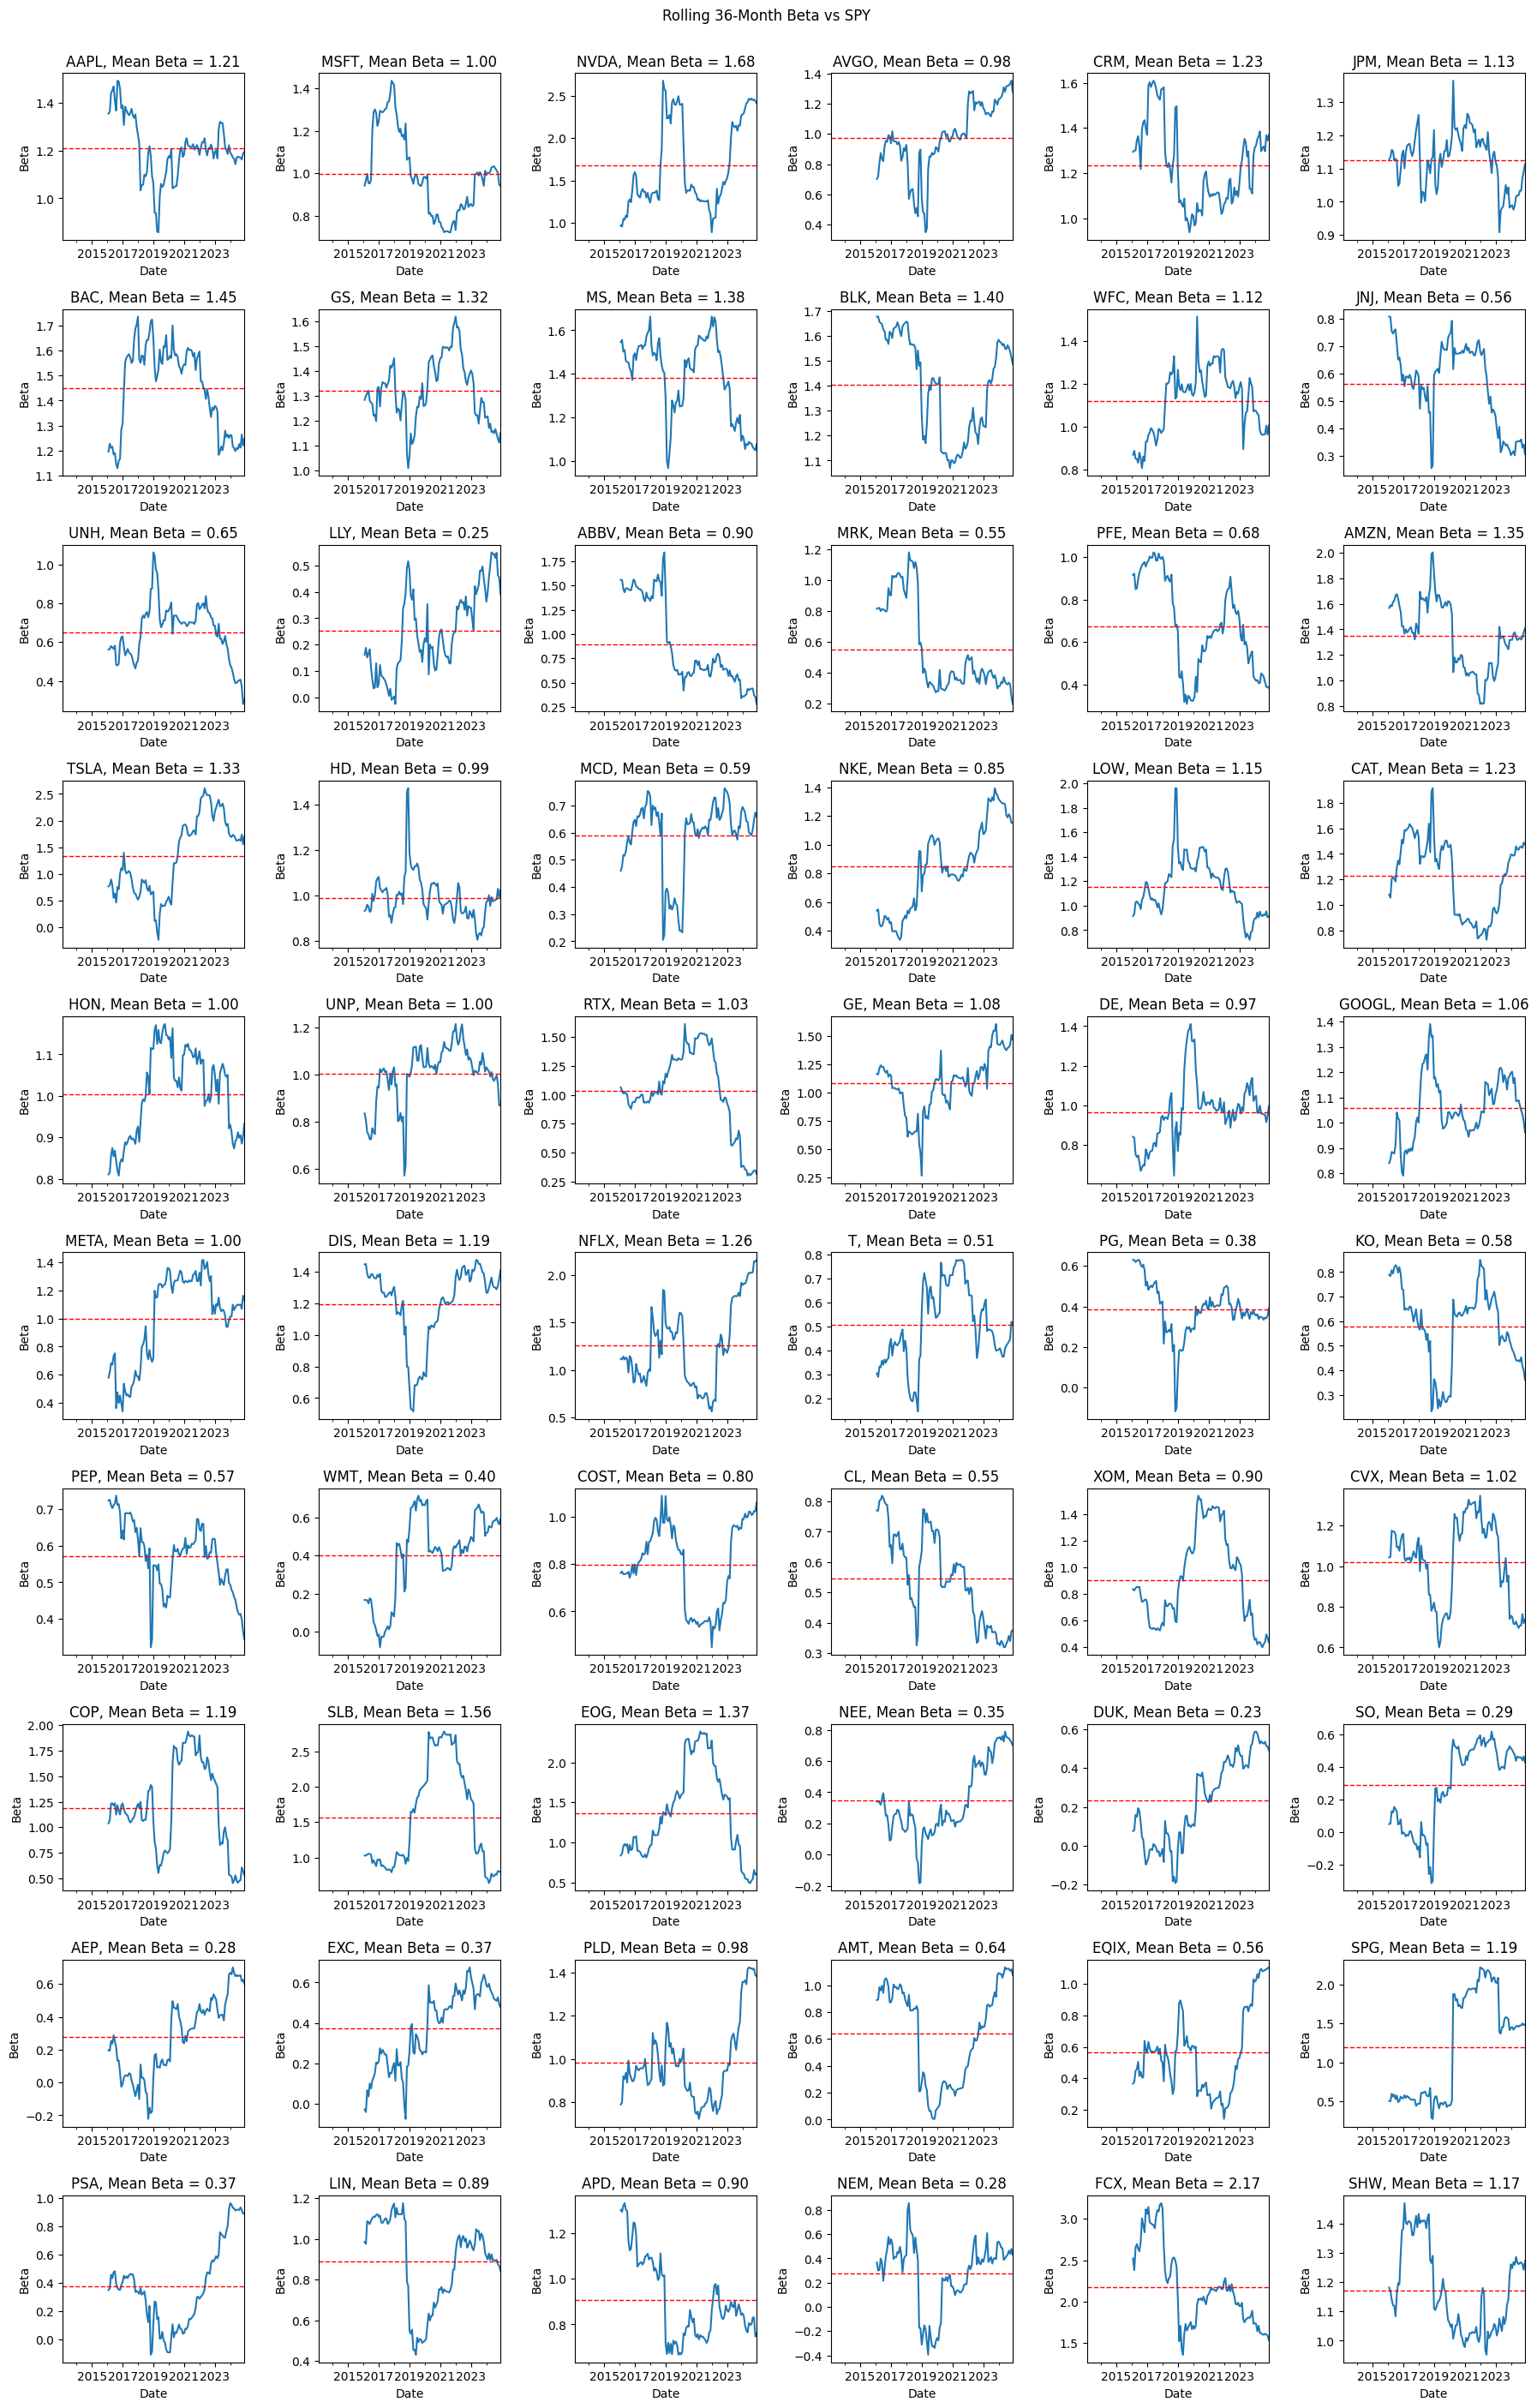

In [8]:
fig, axes = plt.subplots(10, 6, figsize=(18, 28))
axes = axes.flatten()

for i, ticker in enumerate(beta_panel.columns):
    ax = axes[i]
    beta_panel[ticker].plot(ax=ax, linewidth=1.5)
    mean_beta = beta_panel[ticker].mean()
    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")
    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")
    ax.set_ylabel("Beta")

for j in range(len(beta_panel.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)
fig.tight_layout()
plt.savefig("outputs/beta_panel.png")
plt.show()

In [9]:
# 2. Momentum
mom_start = 12 # 12 months lookback
mom_end = 1 # exclude most recent month - noisy
momentum_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < mom_start:
        continue  # Not enough data for the first few months

    window = returns.iloc[i-mom_start:i-mom_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    momentum_panel.loc[date] = compounded

momentum_panel.to_csv("data/signal_momentum_raw.csv")
print(momentum_panel)

                AAPL      MSFT      NVDA      AVGO       CRM       JPM  \
Date                                                                     
2013-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-03-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-04-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-05-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-06-01       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-08-01  0.051980  0.314988  1.367512  0.725579  0.082536  0.285725   
2024-09-01  0.159496  0.258990  1.123252  0.687499  0.107280  0.452157   
2024-10-01  0.315452  0.301165  1.478508  0.911244  0.188168  0.553817   
2024-11-01  0.343209  0.257860  1.694839  0.985214  0.294632  0.518054   
2024-12-01  0.176473  0.064544  1.581451  0.789113  0.123137  0.421125   

                 BAC        GS       

In [10]:
# 3. Size
size_panel = log_market_cap.copy()
size_panel = size_panel.reindex(index=monthly_index)
size_panel = size_panel.reindex(columns=all_tickers)

assert size_panel.index.equals(monthly_index), \
    "Index mismatch between size panel and returns index"

assert size_panel.columns.tolist() == all_tickers, \
    "Column mismatch between size panel and returns columns"

size_panel.to_csv("data/signal_size_raw.csv")

In [11]:
# 4. Low Volatility
vol_window = 12
low_vol_panel = -returns.rolling(window = vol_window, min_periods = 10).std() # Negative for low vol = high score
low_vol_panel = low_vol_panel.reindex(index=monthly_index)
low_vol_panel = low_vol_panel.reindex(columns=all_tickers)
low_vol_panel.to_csv("data/signal_lowvol_raw.csv")

In [12]:
# 5. Long-term Reversal
ltr_start = 36
ltr_end = 12
ltr_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < ltr_start:
        continue  
    
    window = returns.iloc[i-ltr_start:i-ltr_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    ltr_panel.loc[date] = -compounded 

ltr_panel.to_csv("data/signal_ltr_raw.csv")

In [13]:
'''
dates = np.load("data/dates.npy", allow_pickle=True) 
tickers = np.load("data/tickers.npy", allow_pickle=True)  
factors = np.load("data/factors.npy", allow_pickle=True) 


data = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("data/returns.csv", index_col=0, parse_dates=True).reindex(dates)
spy_returns = pd.read_csv("data/spy_returns.csv", index_col=0, parse_dates=True).reindex(dates)
mktcap_panel = pd.read_csv("data/market_cap.csv", index_col=0, parse_dates=True).reindex(dates)
beta_panel = pd.read_csv("data/signal_beta_raw.csv", index_col=0, parse_dates=True)
momentum_panel = pd.read_csv("data/signal_momentum_raw.csv", index_col=0, parse_dates=True)
size_panel = pd.read_csv("data/signal_size_raw.csv", index_col=0, parse_dates=True)
low_vol_panel = pd.read_csv("data/signal_lowvol_raw.csv", index_col=0, parse_dates=True)
ltr_panel = pd.read_csv("data/signal_ltr_raw.csv", index_col=0, parse_dates=True)
'''



print(beta_panel.shape)
print(momentum_panel.shape)
print(size_panel.shape)
print(low_vol_panel.shape)
print(ltr_panel.shape)

(143, 60)
(143, 60)
(143, 60)
(143, 60)
(143, 60)


In [14]:
# Winsorise, Z-score normalisation and Burn-in
# Set values < 1%ile to 1%ile, > 99%ile to 99%ile, across all stocks, at each time t - hence 'cross sectional'
def winsorise(signal_panel: pd.DataFrame, lower = 0.01, upper = 0.99) -> pd.DataFrame:
    def winsorise_row(row):
        lower_bound = row.quantile(lower)
        upper_bound = row.quantile(upper)
        return row.clip(lower=lower_bound, upper=upper_bound)
    
    return signal_panel.apply(winsorise_row, axis=1)

def normalise(signal_panel: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return signal_panel.apply(normalise_row, axis=1)

def trim_burn_in(signal_panel: pd.DataFrame, burn_in_periods = 36) -> pd.DataFrame:
    return signal_panel.iloc[burn_in_periods:]



In [15]:
signals_raw = {
    "beta": beta_panel,
    "momentum": momentum_panel,
    "size": size_panel,
    "low_vol": low_vol_panel,
    "ltr": ltr_panel
}

signals_processed = {
    name: trim_burn_in(winsorise(normalise(panel))) for name, panel in signals_raw.items() 
}

np.save("data/signals_raw.npy", signals_raw)
np.save("data/signals_processed.npy", signals_processed)

In [16]:
# Trim signals due to burn-in
for signal in signals_processed.values():
    print(signal.isna().sum().sum())
    print(signal.shape)

# No NaNs


0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)


## 3. Orthogonalise and weights via Information Coefficient

In [17]:
def residualise(target: pd.DataFrame, controls):
    if isinstance(controls, (pd.DataFrame, pd.Series)):
        controls = [controls]
    elif isinstance(controls, tuple):
        controls = list(controls)
    elif not isinstance(controls, list):
        raise TypeError("controls must be a DataFrame, Series, list, or tuple")

    controls = [
        ctrl.reindex(index=target.index, columns=target.columns)
        if isinstance(ctrl, pd.DataFrame)
        else ctrl.reindex(index=target.index)
        for ctrl in controls
    ]

    residuals = pd.DataFrame(index=target.index, columns=target.columns, dtype=float)

    for t in target.index:
        y = target.loc[t]
        X = pd.concat(
            [ctrl.loc[t].rename(f"ctrl_{i}") for i, ctrl in enumerate(controls)],
            axis=1,
        )

        common_idx = y.index.intersection(X.index)
        y = y.reindex(common_idx)
        X = X.reindex(common_idx)

        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < 2:
            continue

        y_clean = y.loc[valid]
        X_clean = X.loc[valid]
        X_clean = add_constant(X_clean, has_constant="add")

        try:
            model = OLS(y_clean, X_clean).fit()
            residuals.loc[t, X_clean.index] = model.resid
        except Exception:
            continue

    return residuals

# 1. Size orthogonal to beta
size_clean = residualise(signals_processed["size"], signals_processed["beta"])

# 2. low vol orthogonal to beta + size
lowvol_clean = residualise(
    signals_processed["low_vol"],
    [signals_processed["beta"], size_clean],
)

# 3. momentum orthogonal to beta + size + low vol
momentum_clean = residualise(
    signals_processed["momentum"],
    [signals_processed["beta"], size_clean, lowvol_clean],
)

# 4. ltr orthogonal to beta + size + low vol + momentum
ltr_clean = residualise(
    signals_processed["ltr"],
    [signals_processed["beta"], size_clean, lowvol_clean, momentum_clean],
)

signals_cleaned = {
    "beta": signals_processed["beta"],
    "momentum": momentum_clean,
    "size": size_clean,
    "low_vol": lowvol_clean,
    "ltr": ltr_clean
}
    
np.save("data/signals_cleaned.npy", signals_cleaned)

dates = signals_cleaned["beta"].index
factors = list(signals_cleaned.keys())




In [18]:
returns = returns.reindex(dates)

def compute_ic(name: str, signal: pd.DataFrame, returns: pd.DataFrame):
    returns = returns.shift(-1) # align r_{t+1}
    ic_series = pd.DataFrame(index = signal.index, columns = [name])
    
    for t in signal.index:
        x = signal.loc[t]
        r = returns.loc[t]

        valid = x.notna() & r.notna()

        ic = x[valid].corr(r[valid])
        ic_series.loc[t] = ic

    return ic_series



In [19]:
ic_df = pd.DataFrame(index = dates)
for name, signal in signals_processed.items():
    ic_df = pd.concat([ic_df, compute_ic(name, signal, returns)], axis = 1)
ic_df.dropna(inplace = True)
weights_rolling = normalise(ic_df).rolling(window = 24).mean().dropna()
weights_rolling

,beta,momentum,size,low_vol,ltr
Date,,,,,
2018-01-01,0.501215,0.225688,-0.006691,-0.418258,-0.301954
2018-02-01,0.413308,0.200961,-0.019454,-0.315153,-0.279662
2018-03-01,0.342301,0.234213,0.065534,-0.287332,-0.354717
2018-04-01,0.405625,0.221434,0.072365,-0.362001,-0.337423
2018-05-01,0.431410,0.163613,0.118462,-0.381858,-0.331627
...,...,...,...,...,...
2024-07-01,0.069646,0.208352,0.091262,-0.269058,-0.100203
2024-08-01,0.154092,0.120888,0.072062,-0.298672,-0.048370
2024-09-01,0.152594,0.147549,0.148915,-0.303494,-0.145564


In [20]:
t_eval = weights_rolling.index

for name, signal in signals_cleaned.items():
    signals_cleaned[name] = signal.reindex(t_eval)

signal_matrix = np.stack(
    [
        signals_cleaned["beta"].values,   
        signals_cleaned["momentum"].values,     
        signals_cleaned["size"].values,    
        signals_cleaned["low_vol"].values,   
        signals_cleaned["ltr"].values  
    ],
    axis=2   # stack along the 3rd dimension
)

signal_matrix.shape

(83, 60, 5)

In [21]:
weights = weights_rolling.to_numpy()
scores = np.sum(signal_matrix * weights[:, None, :], axis = 2)
scores = pd.DataFrame(
    scores, 
    index = t_eval, 
    columns = all_tickers
)
scores

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.285810,0.176134,2.690839,0.573809,0.510612,0.242637,0.534571,0.271505,0.434677,0.342947,...,-0.220639,0.046787,-0.026266,-0.495322,-0.569922,-0.144473,-0.188126,-0.083708,1.734176,0.390947
2018-02-01,-0.061881,0.052830,2.329196,0.287387,0.289861,0.113057,0.311799,0.076746,0.227817,0.270061,...,-0.084365,0.026862,0.277554,-0.417778,-0.625841,-0.031814,-0.141235,-0.034759,1.135302,0.279406
2018-03-01,-0.182861,0.223969,2.303059,0.096087,0.047230,0.159051,0.428446,0.000109,0.148000,0.137572,...,0.007421,-0.057903,0.385664,-0.427661,-0.547631,-0.116452,-0.269669,-0.139643,0.610800,0.110478
2018-04-01,-0.007654,0.266363,2.423020,0.083300,0.025330,0.137580,0.427568,-0.043870,0.126959,0.115515,...,-0.166118,-0.062088,0.195769,-0.523315,-0.725782,-0.156203,-0.405214,-0.148243,0.921941,0.069285
2018-05-01,0.208230,0.157677,2.088048,0.262837,-0.043245,0.024284,0.408184,-0.149318,0.041918,0.030041,...,-0.122791,-0.070237,0.163418,-0.617543,-0.835473,-0.223104,-0.523891,-0.318659,1.118206,0.084651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.064749,0.008512,0.998863,0.512564,0.079275,-0.008788,-0.027094,0.006797,0.140781,-0.173569,...,0.115054,0.065425,-0.221033,-0.106306,-0.102951,-0.225414,-0.365900,0.346317,0.192901,0.081570
2024-08-01,0.000438,0.018249,1.030642,0.470788,0.297261,-0.155392,-0.152828,-0.122708,0.161239,-0.006484,...,0.352429,0.223408,-0.093877,-0.134128,0.135601,-0.269946,-0.266041,0.384388,0.218125,0.193331
2024-09-01,0.129334,0.171302,1.283668,0.646703,0.231726,0.071258,-0.138421,-0.020066,0.145157,-0.096969,...,0.272723,0.092800,-0.212232,-0.252650,0.018020,-0.268400,-0.349959,0.305226,0.187852,0.158355


In [22]:
rank_df = scores.rank(axis=1, ascending=False)
rank_df

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,14.0,18.0,1.0,5.0,8.0,16.0,7.0,15.0,10.0,13.0,...,40.0,23.0,26.0,47.0,48.0,33.0,36.0,29.0,2.0,12.0
2018-02-01,31.0,23.0,1.0,11.0,10.0,19.0,9.0,21.0,15.0,14.0,...,33.0,26.0,13.0,45.0,56.0,28.0,37.0,29.0,3.0,12.0
2018-03-01,38.0,13.0,1.0,21.0,24.0,15.0,6.0,26.0,16.0,17.0,...,25.0,30.0,7.0,49.0,56.0,35.0,43.0,37.0,5.0,20.0
2018-04-01,26.0,11.0,1.0,20.0,24.0,17.0,7.0,28.0,18.0,19.0,...,37.0,29.0,14.0,52.0,59.0,34.0,47.0,33.0,4.0,22.0
2018-05-01,15.0,18.0,1.0,13.0,29.0,25.0,11.0,33.0,23.0,24.0,...,32.0,31.0,17.0,52.0,59.0,40.0,49.0,45.0,4.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,32.0,24.0,1.0,3.0,20.0,27.0,28.0,26.0,15.0,40.0,...,16.0,22.0,46.0,35.0,34.0,47.0,59.0,7.0,11.0,19.0
2024-08-01,25.0,22.0,1.0,4.0,10.0,42.0,41.0,37.0,16.0,26.0,...,8.0,12.0,33.0,39.0,18.0,51.0,50.0,5.0,13.0,15.0
2024-09-01,18.0,14.0,1.0,3.0,11.0,24.0,38.0,31.0,16.0,35.0,...,8.0,22.0,42.0,44.0,29.0,46.0,52.0,7.0,13.0,15.0


## 4. Evaluate Portfolio

In [23]:
# Long top 20%, Short bottom 20%
def long_short_weights(scores, quantile=0.2):

    w = pd.DataFrame(
        0.0,
        index = scores.index,
        columns = scores.columns
    )

    for time, row in scores.iterrows():
        n = int(np.floor(len(row) * quantile))

        ranked = row.sort_values(ascending = False)
        longs = ranked.index[:n]
        shorts = ranked.index[-n:]

        w.loc[time, longs] = 1.0 / n
        w.loc[time, shorts] = -1.0 / n

    return w



In [24]:
returns_eval = returns.shift(-1).reindex(t_eval)
returns_eval

Ticker,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.061892,0.038810,-0.047642,-0.058338,0.041554,-0.046064,-0.006350,0.003120,-0.022264,-0.046734,...,-0.114188,-0.046509,-0.062252,-0.013730,-0.032267,-0.045889,-0.024646,-0.118829,-0.169163,-0.142044
2018-02-01,-0.055735,-0.201938,0.054543,0.042230,-0.044003,-0.011007,-0.044852,-0.067992,-0.014132,-0.048021,...,-0.006156,0.049585,0.017971,-0.018068,-0.253920,-0.055267,0.036862,-0.102443,-0.011621,-0.004858
2018-03-01,-0.015133,0.019875,0.020063,-0.063778,0.078880,0.027271,-0.012247,0.001409,-0.032744,-0.020704,...,0.056712,0.032169,0.012810,-0.086375,0.099255,0.102855,-0.005969,-0.008623,0.000195,0.041224
2018-04-01,0.122893,0.034757,-0.029437,0.019885,0.039739,-0.005437,0.094153,-0.029853,0.024117,0.056000,...,0.001603,-0.026809,0.024515,0.007066,-0.031698,0.021386,0.066090,0.038325,-0.069268,0.043909
2018-05-01,-0.005614,-0.065684,0.028213,0.041062,0.042164,-0.035824,-0.038128,-0.025630,-0.068140,-0.113063,...,-0.024172,0.044771,0.073057,-0.006519,0.186043,0.015734,-0.002513,0.034003,0.043267,0.028259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,0.030684,0.066755,0.021775,0.016470,-0.046413,0.062176,0.013231,0.010856,0.028467,0.032259,...,-0.093262,0.033902,0.086778,0.048106,-0.080549,0.024076,0.037234,-0.014770,0.117912,-0.005496
2024-08-01,0.018473,0.005942,0.031888,0.037234,0.042931,0.065547,0.057752,-0.026609,0.051542,0.093803,...,-0.047484,0.051096,0.009930,0.100323,0.200441,-0.009397,-0.032942,-0.026840,0.047416,0.001895
2024-09-01,-0.030902,0.031845,-0.038246,-0.085324,0.000376,0.042060,-0.012669,0.059026,0.038557,-0.038893,...,-0.039327,0.009382,0.013132,0.024249,-0.046071,-0.031585,-0.060242,0.139092,0.014751,-0.003761


In [25]:
weights = long_short_weights(scores)
portfolio_returns = (weights * returns_eval).sum(axis = 1)
portfolio = (1 + portfolio_returns).cumprod()

spy_eval = spy_returns.reindex(t_eval)
benchmark = (1 + spy_eval).cumprod()

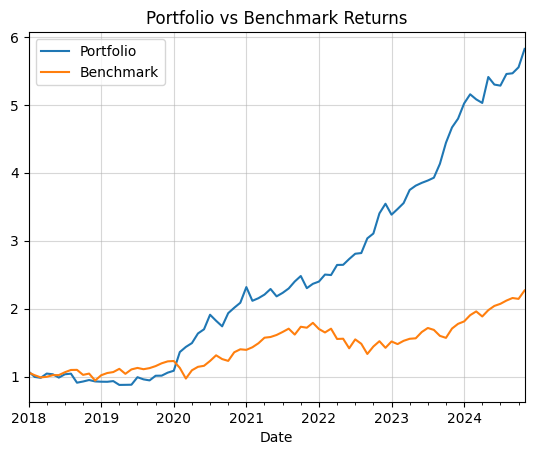

In [26]:
fig, ax = plt.subplots()

portfolio.plot(ax = ax, label = 'Portfolio')
benchmark.plot(ax = ax, label = 'Benchmark')
ax.set_title('Portfolio vs Benchmark Returns')
ax.grid(alpha = 0.5)
ax.legend()
plt.savefig("outputs/Portfolio_vs_Benchmark.png")

## 5. Analytics

In [27]:
mean = portfolio_returns.mean()
std = portfolio_returns.std()
sharpe = np.sqrt(12) * mean / std
total_return = portfolio.iloc[-1] - 1
annual_return = (1 + total_return) ** (12 / len(portfolio)) - 1
running_max = portfolio.cummax()
drawdown = portfolio / running_max - 1
max_dd = drawdown.min()


print(f"Mean Return: {mean * 100:.2f}%")
print(f"Mean Std: {std * 100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Total Returns: {total_return * 100:.0f}%")
print(f"Annual Return: {annual_return * 100:.0f}%")
print(f"Max drawdown: {max_dd * 100:.0f}%")


Mean Return: 2.28%
Mean Std: 5.29%
Sharpe Ratio: 1.49
Total Returns: 482%
Annual Return: 29%
Max drawdown: -18%


In [28]:
# Drawdown
running_max = portfolio.cummax()
drawdown = portfolio / running_max - 1
max_dd = drawdown.min()

print(f"Max drawdown: {max_dd * 100:.0f}%")


Max drawdown: -18%


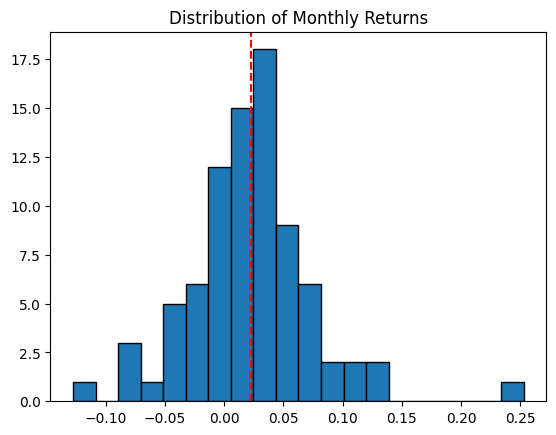

In [29]:
plt.hist(portfolio_returns.values, bins = 20, edgecolor = 'black')
plt.axvline(mean, color = 'r', ls = '--')
plt.title('Distribution of Monthly Returns')
plt.savefig('outputs/Distribution of Monthly Returns.png')